# CA interaction results

This notebook only reads results saved by `cf_ca_interaction_compute.ipynb`. Adjacent salt transitions are shown first, followed by their cumulative interaction change relative to the selected reference. The optional direct lowest-to-highest result is used only as a closure check. Figures use at most two columns and contain no titles or explanatory annotations beyond axes, ticks, and legends.

In [1]:
from __future__ import annotations

import csv
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import cf_ca_interaction as interaction

HERE = Path.cwd().resolve()
if not (HERE / "cf_ca_interaction.py").exists():
    raise RuntimeError("Run this notebook from smpl/curvefit")

# 1. SETTINGS THAT MUST MATCH BETWEEN COMPUTE AND RESULTS.
# Copy this whole block into the results notebook before loading saved results.
# Scientific default: anisotropic geometry with adjacent-state comparisons.
FIT_SOURCE = "aniso"  # "iso" or "aniso"
COMPARISON_MODE = "adjacent"  # "adjacent" or "single_reference"
REFERENCE_CONDITION = "zero"  # "zero" or "highest"
ANISOTROPIC_GEOMETRY = True  # True for anisotropic geometry; False for isotropic geometry.
LOCAL_EXPANSION_RANGE_MULTIPLIER = 1.0  # ell = this value / k_eff; the note uses 1.0.
# END MATCHED SETTINGS

if COMPARISON_MODE not in {"adjacent", "single_reference"}:
    raise ValueError("COMPARISON_MODE must be 'adjacent' or 'single_reference'")
if REFERENCE_CONDITION not in {"zero", "highest"}:
    raise ValueError("REFERENCE_CONDITION must be 'zero' or 'highest'")
REFERENCE_TAG = "0mM" if REFERENCE_CONDITION == "zero" else "highest_salt"
COMPARISON_TAG = "_adjacent" if COMPARISON_MODE == "adjacent" else ""  # Keep the former single-reference path compatible.
OUTPUT_SUFFIX = "_geometry_aniso" if ANISOTROPIC_GEOMETRY else ""
OUTPUT_DIR = HERE / "output" / f"ca_interaction_refactored_{REFERENCE_TAG}_{FIT_SOURCE}{COMPARISON_TAG}{OUTPUT_SUFFIX}"
COEFFICIENT_TABLE = OUTPUT_DIR / "effective_local_cell_coefficients.csv"
FIT_INPUT_TABLE = OUTPUT_DIR / "radial_fit_inputs.csv"
INVARIANT_MOMENT_TABLE = OUTPUT_DIR / "local_invariant_moments.csv"
STRUCTURE_HISTOGRAM_TABLE = OUTPUT_DIR / "local_structure_histograms.csv"
STRUCTURE_CORRELATION_TABLE = OUTPUT_DIR / "local_structure_correlations.csv"
INDEPENDENT_COEFFICIENT_TABLE = OUTPUT_DIR / "independent_fourth_order_coefficients.csv"
CUMULATIVE_COEFFICIENT_TABLE = OUTPUT_DIR / "cumulative_local_coefficients.csv"

# 2. RESULTS ALWAYS RELOAD SAVED TABLES; NO RECOMPUTE SWITCH IS NEEDED HERE.
# After loading new data, rerun this notebook from the first cell.

# 3. RESULT-ONLY INTERPRETATION AND ADVANCED-RESULT DISPLAY OPTIONS.
CONDITIONAL_G0_OVER_KREF_BOUNDS = (100.0, 2000.0)
CONDITIONAL_D0_KREF_BOUNDS = (0.1, 1.0)
CONDITIONAL_REFERENCE_GRID_SIZE = 17
CONDITIONAL_ENVELOPE_STANDARD_DEVIATIONS = 1.0
CONDITIONAL_REFERENCE_MODE = "family"  # "fixed" uses the stated g0,D0; "family" scans plausible references.
CONDITIONAL_CUTOFF_MODE = "finite_cutoff"  # "short_range" sets f2=f4=1; "finite_cutoff" retains f2,f4.
if CONDITIONAL_REFERENCE_MODE not in {"fixed", "family"}:
    raise ValueError("CONDITIONAL_REFERENCE_MODE must be 'fixed' or 'family'")
if CONDITIONAL_CUTOFF_MODE not in {"short_range", "finite_cutoff"}:
    raise ValueError("CONDITIONAL_CUTOFF_MODE must be 'short_range' or 'finite_cutoff'")
SHOW_DISTANT_CORRECTION_IN_FIT = False  # Optional overlay; the primary reconstruction is always the random-wave fit.
FIXED_REFERENCE_G0_OVER_KREF = 5.0
FIXED_REFERENCE_D0_KREF = 1.0
RECONSTRUCTION_KS_WARNING = 0.08
PROJECTION_UNEXPLAINED_WARNING = 0.20
LOCAL_K2_HISTOGRAM_RANGE = (0.0, 5.0)
LOCAL_K4_HISTOGRAM_RANGE = (-0.25, 0.25)
plt.rcParams.update({"figure.dpi": 130, "savefig.dpi": 190, "axes.grid": True, "grid.alpha": 0.22})

## Load the calculated results

Run `cf_ca_interaction_compute.ipynb` first whenever the input fit or analysis settings change.

In [2]:
if not COEFFICIENT_TABLE.exists() or not FIT_INPUT_TABLE.exists():
    raise FileNotFoundError("Run cf_ca_interaction_compute.ipynb first")
with COEFFICIENT_TABLE.open(newline="", encoding="utf-8") as handle:
    coefficient_rows = list(csv.DictReader(handle))
with FIT_INPUT_TABLE.open(newline="", encoding="utf-8") as handle:
    fit_input_rows = list(csv.DictReader(handle))
if not INVARIANT_MOMENT_TABLE.exists() or not INDEPENDENT_COEFFICIENT_TABLE.exists():
    raise FileNotFoundError("Run the direct local inference cell in cf_ca_interaction_compute.ipynb")
with INVARIANT_MOMENT_TABLE.open(newline="", encoding="utf-8") as handle:
    invariant_moment_rows = list(csv.DictReader(handle))
with INDEPENDENT_COEFFICIENT_TABLE.open(newline="", encoding="utf-8") as handle:
    independent_coefficient_rows = list(csv.DictReader(handle))
structure_histogram_rows = []
structure_correlation_rows = []
if STRUCTURE_HISTOGRAM_TABLE.exists() and STRUCTURE_CORRELATION_TABLE.exists():
    with STRUCTURE_HISTOGRAM_TABLE.open(newline="", encoding="utf-8") as handle:
        structure_histogram_rows = list(csv.DictReader(handle))
    with STRUCTURE_CORRELATION_TABLE.open(newline="", encoding="utf-8") as handle:
        structure_correlation_rows = list(csv.DictReader(handle))
else:
    print("Measured structure tables are absent; rerun the local inference cell in the compute notebook.")
fit_by_salt = {float(row["concentration_mM"]): row for row in fit_input_rows}
salt = np.array([float(row["concentration_mM"]) for row in coefficient_rows])
if any(float(value) not in fit_by_salt for value in salt):
    raise RuntimeError("coefficient and fitted-spectrum tables contain different conditions")
k_eff = np.array([float(fit_by_salt[float(value)]["k_eff"]) for value in salt])
r_sigma_k = np.array([float(fit_by_salt[float(value)]["r_sigma_k"]) for value in salt])
reference_index = int(np.argmin(salt) if REFERENCE_CONDITION == "zero" else np.argmax(salt))
reference_salt = salt[reference_index]
saved_reference = {float(row["reference_concentration_mM"]) for row in fit_input_rows if row.get("reference_concentration_mM") not in (None, "")}
if saved_reference and (len(saved_reference) != 1 or not np.isclose(next(iter(saved_reference)), reference_salt)):
    raise RuntimeError("The result files were calculated with a different reference condition")
saved_modes = {row.get("comparison_mode") for row in fit_input_rows if row.get("comparison_mode")}
if saved_modes and saved_modes != {COMPARISON_MODE}:
    raise RuntimeError("The result files were calculated with a different comparison mode")
saved_expansion_ranges = {float(row.get("local_expansion_range_times_kref", row.get("local_cell_length_times_kref"))) for row in coefficient_rows if row.get("local_expansion_range_times_kref", row.get("local_cell_length_times_kref")) not in (None, "")}
if saved_expansion_ranges and (len(saved_expansion_ranges) != 1 or not np.isclose(next(iter(saved_expansion_ranges)), LOCAL_EXPANSION_RANGE_MULTIPLIER)):
    raise RuntimeError("The result files were calculated with a different LOCAL_EXPANSION_RANGE_MULTIPLIER")
if COMPARISON_MODE == "single_reference" and not np.allclose([float(coefficient_rows[reference_index]["delta_c2_kref"]), float(coefficient_rows[reference_index]["delta_c4_kref3"])], 0.0, atol=1e-12):
    raise RuntimeError("The selected reference row does not have zero coefficient change")
k_ref = k_eff[reference_index]
delta_c2 = np.array([float(row["delta_c2_kref"]) for row in coefficient_rows])
delta_c4 = np.array([float(row["delta_c4_kref3"]) for row in coefficient_rows])
source_salt_by_target = {float(row["concentration_mM"]): float(row.get("source_concentration_mM", reference_salt)) for row in coefficient_rows}
coefficient_covariances = np.array([[[float(row["cov_c2_c2"]), float(row["cov_c2_c4"])], [float(row["cov_c2_c4"]), float(row["cov_c4_c4"])]] for row in coefficient_rows])
if CUMULATIVE_COEFFICIENT_TABLE.exists():
    with CUMULATIVE_COEFFICIENT_TABLE.open(newline="", encoding="utf-8") as handle:
        cumulative_by_salt = {float(row["concentration_mM"]): row for row in csv.DictReader(handle)}
    cumulative_delta_c2 = np.array([float(cumulative_by_salt[float(value)]["delta_c2_kref"]) for value in salt])
    cumulative_delta_c4 = np.array([float(cumulative_by_salt[float(value)]["delta_c4_kref3"]) for value in salt])
    cumulative_coefficient_covariances = np.array([[[float(cumulative_by_salt[float(value)]["cov_c2_c2"]), float(cumulative_by_salt[float(value)]["cov_c2_c4"])], [float(cumulative_by_salt[float(value)]["cov_c2_c4"]), float(cumulative_by_salt[float(value)]["cov_c4_c4"])]] for value in salt])
else:
    cumulative_delta_c2, cumulative_delta_c4 = delta_c2.copy(), delta_c4.copy()
    cumulative_coefficient_covariances = coefficient_covariances.copy()
projection_unexplained = np.array([float(row.get("projection_unexplained_fraction", np.nan)) for row in coefficient_rows])
if any(row.get("inference_method") != "linked_maximum_entropy" for row in coefficient_rows):
    raise RuntimeError("The saved coefficients predate direct linked inference; rerun the compute notebook")
colors = plt.cm.viridis(np.linspace(0.08, 0.92, len(salt)))
print(f"loaded {len(salt)} conditions; reference={reference_salt:g} mM; k_ref={k_ref:.8g}")

loaded 8 conditions; reference=0 mM; k_ref=0.052411293


## Anisotropy input

When anisotropic geometry is enabled, these are the fixed principal stretches and Hencky strains supplied by the scattering fit. They are inputs to the geometric calculation, not interaction-fit parameters.

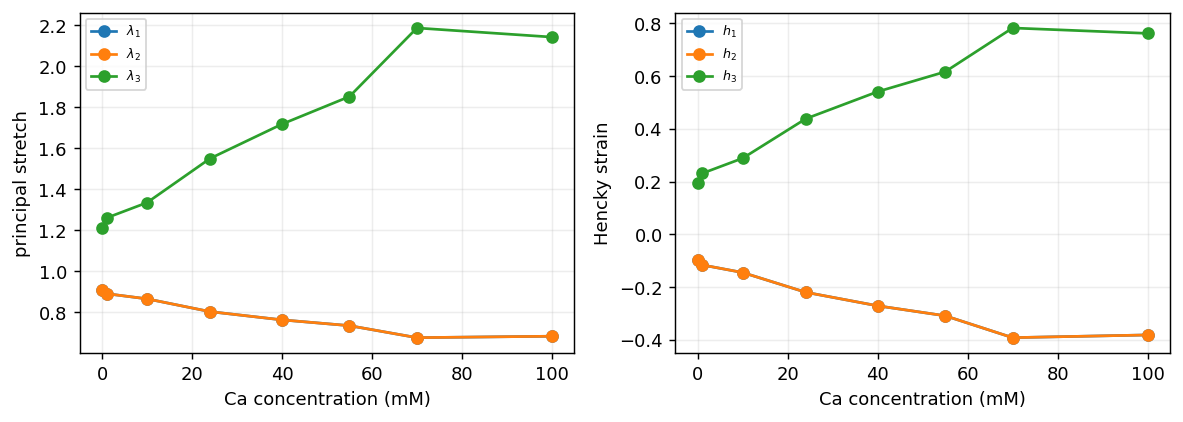

In [3]:
anisotropy_path = OUTPUT_DIR / "anisotropy_inputs.csv"
if ANISOTROPIC_GEOMETRY:
    if not anisotropy_path.exists():
        raise FileNotFoundError("Run the compute notebook with ANISOTROPIC_GEOMETRY=True")
    with anisotropy_path.open(newline="", encoding="utf-8") as handle:
        anisotropy_rows = list(csv.DictReader(handle))
    anisotropy_salt = np.array([float(row["concentration_mM"]) for row in anisotropy_rows])
    principal_stretch = np.array([[float(row[f"lambda{index}"]) for index in (1,2,3)] for row in anisotropy_rows])
    principal_strain = np.array([[float(row[f"h{index}"]) for index in (1,2,3)] for row in anisotropy_rows])
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.35))
    for index in range(3):
        axes[0].plot(anisotropy_salt, principal_stretch[:,index], marker="o", label=rf"$\lambda_{index+1}$")
        axes[1].plot(anisotropy_salt, principal_strain[:,index], marker="o", label=rf"$h_{index+1}$")
    for axis, ylabel in zip(axes, (r"principal stretch", r"Hencky strain")):
        axis.set(xlabel="Ca concentration (mM)", ylabel=ylabel); axis.legend(fontsize=7)
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "anisotropy_inputs.png"); plt.show()
else:
    print("anisotropic geometry disabled")

## 1. Measured local structure

The distributions of $\kappa$, $\kappa'$, and $\kappa\tau$ are the primary observations. Correlations are calculated from their magnitudes because the signs of $\kappa'$ and $\kappa\tau$ cancel under the symmetries of the random-wave ensemble. The coefficient plots that follow summarize only the part represented by the local expression in the note.

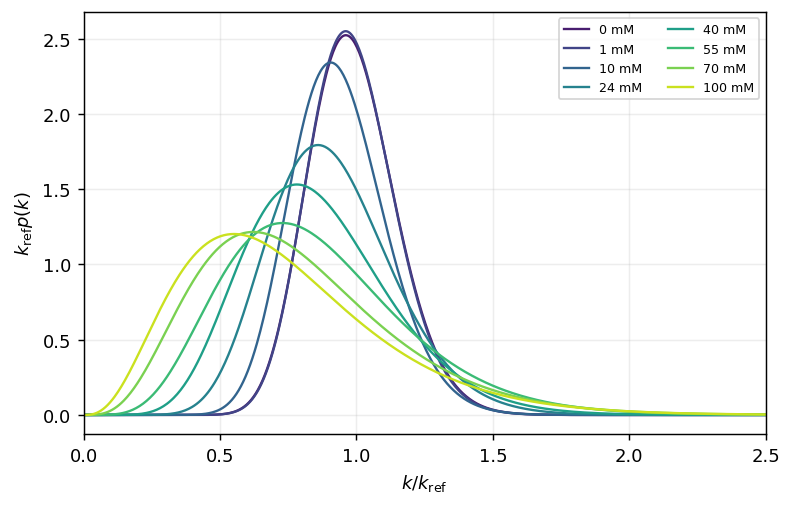

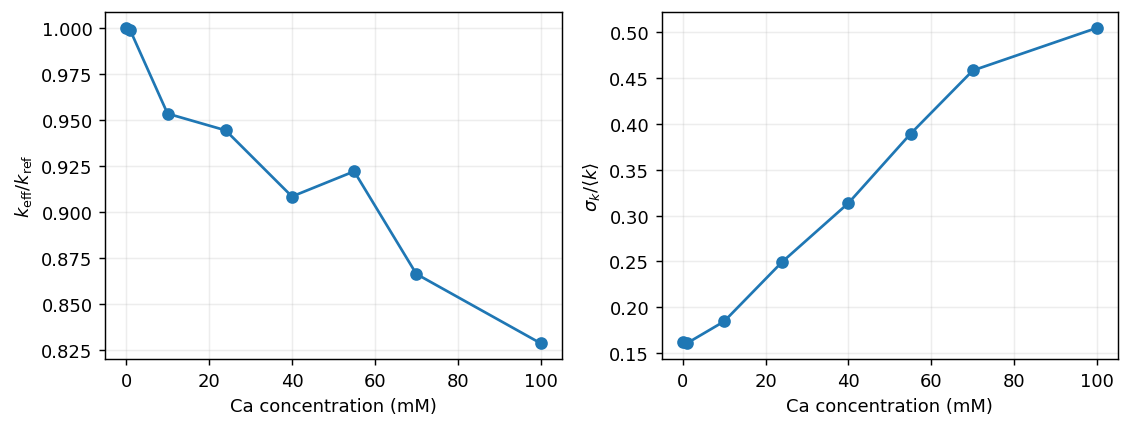

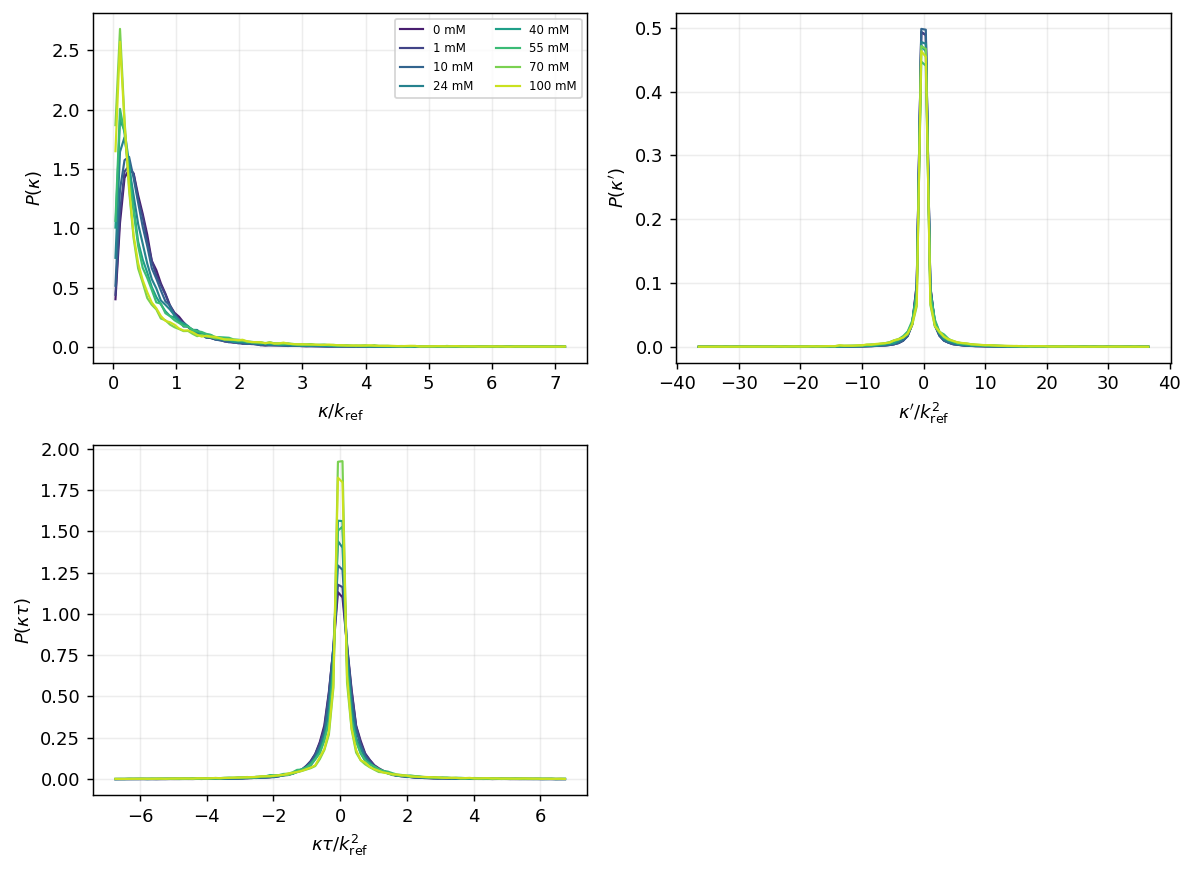

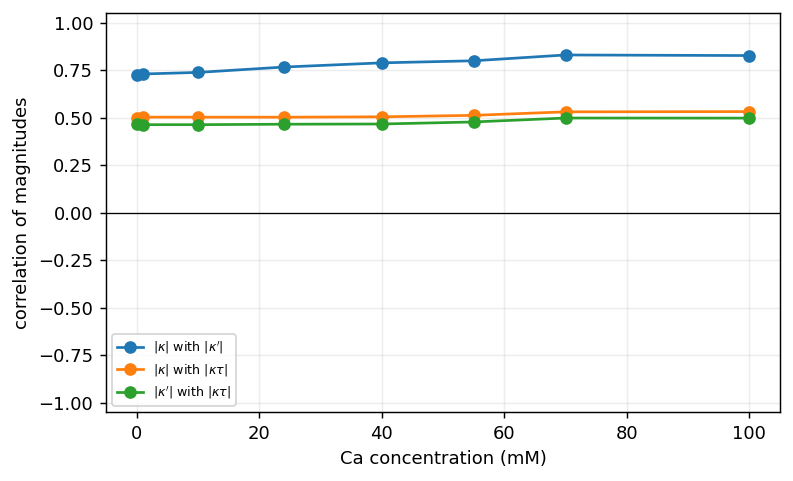

In [4]:
reduced_k = np.linspace(0.001, 2.5, 600)
fig, axis = plt.subplots(figsize=(6.2, 4.0))
for color,concentration,condition_k_eff,condition_width in zip(colors,salt,k_eff,r_sigma_k):
    reduced_density = k_ref*interaction.gamma_radial_density(reduced_k*k_ref, condition_k_eff, condition_width)
    axis.plot(reduced_k, reduced_density, color=color, lw=1.3, label=f"{concentration:g} mM")
axis.set(xlabel=r"$k/k_{\rm ref}$", ylabel=r"$k_{\rm ref}p(k)$", xlim=(0,2.5))
axis.legend(fontsize=7, ncol=2)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "radial_spectrum_systematic_change.png"); plt.show()
fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.4), sharex=True)
axes[0].plot(salt, k_eff/k_ref, marker="o")
axes[1].plot(salt, r_sigma_k, marker="o")
axes[0].set(xlabel="Ca concentration (mM)", ylabel=r"$k_{\rm eff}/k_{\rm ref}$")
axes[1].set(xlabel="Ca concentration (mM)", ylabel=r"$\sigma_k/\langle k\rangle$")
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "radial_spectrum_parameter_changes.png"); plt.show()

if structure_histogram_rows:
    fig, axes = plt.subplots(2, 2, figsize=(9.2, 6.8))
    structure_specs = (("kappa", r"$\kappa/k_{\rm ref}$", r"$P(\kappa)$"), ("kappa_prime", r"$\kappa'/k_{\rm ref}^2$", r"$P(\kappa')$"), ("kappa_tau", r"$\kappa\tau/k_{\rm ref}^2$", r"$P(\kappa\tau)$"))
    for axis, (variable, xlabel, ylabel) in zip(axes.flat, structure_specs):
        for color, concentration in zip(colors, salt):
            rows = [row for row in structure_histogram_rows if float(row["concentration_mM"]) == concentration and row["variable"] == variable]
            axis.plot([float(row["coordinate"]) for row in rows], [float(row["density"]) for row in rows], color=color, lw=1.2, label=f"{concentration:g} mM")
        axis.set(xlabel=xlabel, ylabel=ylabel)
    axes[0,0].legend(fontsize=6.5, ncol=2)
    axes[1,1].remove()
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "measured_local_structure_distributions.png"); plt.show()
if structure_correlation_rows:
    correlation_by_salt = {float(row["concentration_mM"]): row for row in structure_correlation_rows}
    fig, axis = plt.subplots(figsize=(6.2, 3.8))
    for column, label in (("corr_kappa_kappa_prime", r"$|\kappa|$ with $|\kappa'|$"), ("corr_kappa_kappa_tau", r"$|\kappa|$ with $|\kappa\tau|$"), ("corr_kappa_prime_kappa_tau", r"$|\kappa'|$ with $|\kappa\tau|$")):
        axis.plot(salt, [float(correlation_by_salt[float(value)][column]) for value in salt], marker="o", label=label)
    axis.axhline(0.0, color="k", lw=0.7)
    axis.set(xlabel="Ca concentration (mM)", ylabel="correlation of magnitudes", ylim=(-1.05,1.05))
    axis.legend(fontsize=7)
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "measured_local_structure_correlations.png"); plt.show()




## 2. Local expression and coefficient summaries

The default coefficients come from direct conditioned random-wave sampling over the local expansion range. The report first lists the target and fitted $K_2,K_4$ sample estimates used by that calculation. Separate fourth-order coefficients and the unrepresented fraction show when the two-number summary is incomplete. The optional contour-trace estimates are reported later with ensemble brackets.

random-wave line density      <k2>/k_ref^2: target, fit, difference       <k4>/k_ref^4: target, fit, difference
0mM_to_1mM            0.527379,  0.527379,  2.56e-10       0.0673043,  0.0673043,  3.73e-09
1mM_to_10mM           0.517117,  0.517117,  7.38e-11       0.0777403,  0.0777403,  2.79e-11
10mM_to_24mM          0.596347,  0.596347, -1.11e-15       0.131116,  0.131116,  9.16e-16
24mM_to_40mM          0.700199,  0.700199,  6.11e-15       0.270518,  0.270518,  1.31e-13
40mM_to_55mM          0.892682,  0.892682,  9.59e-13       0.490676,  0.490676,  1.85e-12
55mM_to_70mM          1.03204,  1.03204, -1.45e-10       0.968366,  0.968366, -5.26e-10
70mM_to_100mM         1.2008,  1.2008, -2.28e-08       1.65962,  1.65962,  1.00e-07


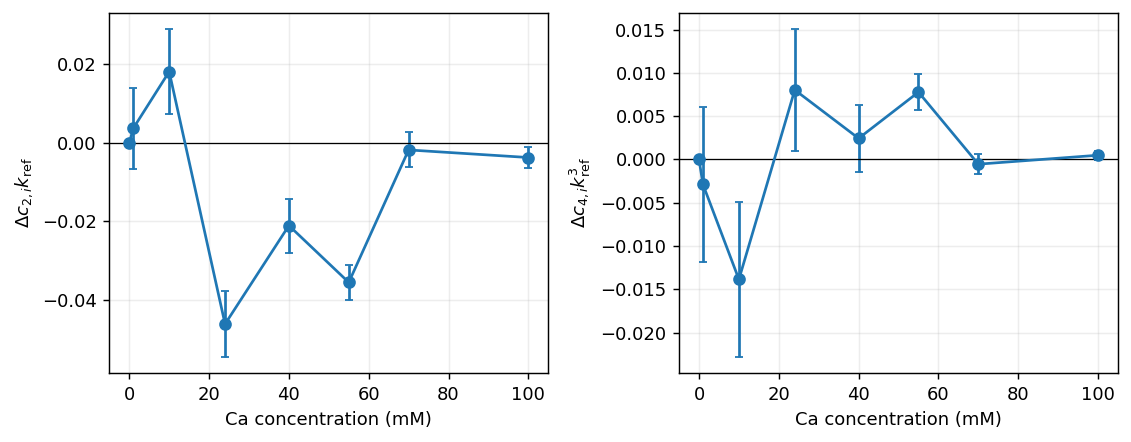

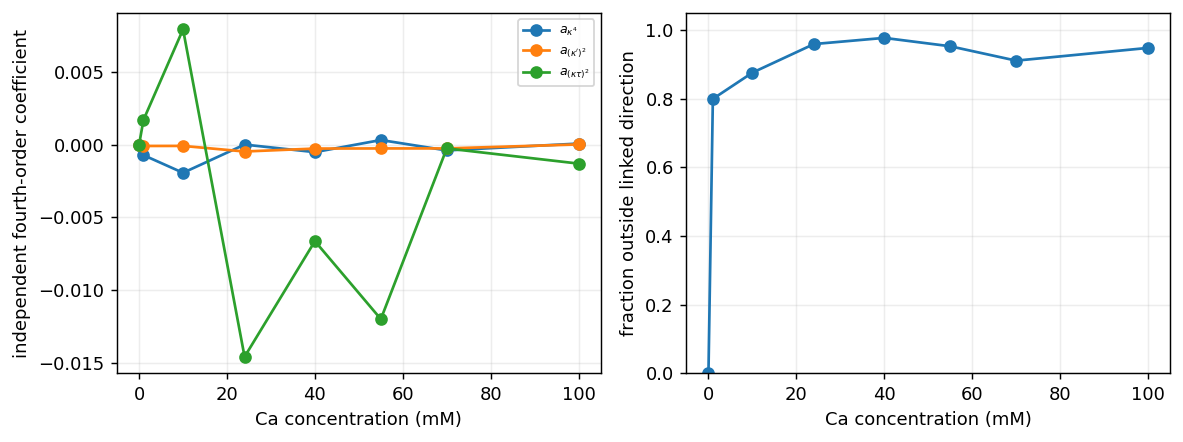

In [5]:
randomwave_mean_columns = {"randomwave_target_K2_over_ksource", "randomwave_fitted_K2_over_ksource", "randomwave_target_K4_over_ksource3", "randomwave_fitted_K4_over_ksource3"}
if coefficient_rows and randomwave_mean_columns.issubset(coefficient_rows[0]):
    print("random-wave line density      <k2>/k_ref^2: target, fit, difference       <k4>/k_ref^4: target, fit, difference")
    for row in coefficient_rows:
        if row["randomwave_target_K2_over_ksource"].lower() == "nan":
            continue
        source_scale = float(row["source_k_eff"]) / k_ref
        k2_target = float(row["randomwave_target_K2_over_ksource"]) * source_scale**2 / LOCAL_EXPANSION_RANGE_MULTIPLIER
        k2_fit = float(row["randomwave_fitted_K2_over_ksource"]) * source_scale**2 / LOCAL_EXPANSION_RANGE_MULTIPLIER
        k4_target = float(row["randomwave_target_K4_over_ksource3"]) * source_scale**4 / LOCAL_EXPANSION_RANGE_MULTIPLIER
        k4_fit = float(row["randomwave_fitted_K4_over_ksource3"]) * source_scale**4 / LOCAL_EXPANSION_RANGE_MULTIPLIER
        print(f"{row['pair_id']:<20} {k2_target: .6g}, {k2_fit: .6g}, {k2_fit-k2_target: .2e}      {k4_target: .6g}, {k4_fit: .6g}, {k4_fit-k4_target: .2e}")
else:
    print("Random-wave fitted/target K2,K4 values are absent; rerun random-wave sampling in the compute notebook.")

coefficient_errors = np.sqrt(np.maximum(np.diagonal(coefficient_covariances, axis1=1, axis2=2), 0.0))
fig, axes = plt.subplots(1, 2, figsize=(8.8, 3.5), sharex=True)
axes[0].errorbar(salt, delta_c2, yerr=coefficient_errors[:,0], marker="o", capsize=2)
axes[1].errorbar(salt, delta_c4, yerr=coefficient_errors[:,1], marker="o", capsize=2)
for axis, label in zip(axes, (r"$\Delta c_{2,i} k_{\rm ref}$", r"$\Delta c_{4,i} k_{\rm ref}^3$")):
    axis.axhline(0, color="k", lw=0.7)
    axis.set(xlabel="Ca concentration (mM)", ylabel=label)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "effective_c2_c4_changes.png")
plt.show()

independent_by_salt = {float(row["concentration_mM"]): row for row in independent_coefficient_rows}
independent_components = {name: np.array([float(independent_by_salt[float(value)][name]) for value in salt]) for name in ("a_kappa4_kref3", "a_kappaprime2_kref3", "a_kappatau2_kref3", "residual_fraction")}
fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.5), sharex=True)
for name,label in (("a_kappa4_kref3", r"$a_{\kappa^4}$"), ("a_kappaprime2_kref3", r"$a_{(\kappa')^2}$"), ("a_kappatau2_kref3", r"$a_{(\kappa\tau)^2}$")):
    axes[0].plot(salt, independent_components[name], marker="o", label=label)
axes[1].plot(salt, independent_components["residual_fraction"], marker="o")
axes[0].set(xlabel="Ca concentration (mM)", ylabel=r"independent fourth-order coefficient"); axes[0].legend(fontsize=7)
axes[1].set(xlabel="Ca concentration (mM)", ylabel="fraction outside linked direction", ylim=(0, 1.05))
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "independent_fourth_order_diagnostic.png"); plt.show()
for concentration, fraction in zip(salt, projection_unexplained):
    if np.isfinite(fraction) and fraction > PROJECTION_UNEXPLAINED_WARNING:
        print(f"WARNING: at {concentration:g} mM, K2,K4 leave {fraction:.1%} of the fitted log-density variation unexplained.")

## 3. Validate what the two coefficients describe

The reported $\Delta c_2$ and $\Delta c_4$ are fitted to the conditioned random-wave samples. Each panel shows the random-wave distribution, its random-wave fit, and—when saved—the directly traced-contour distribution as a resolution and finite-size comparison. No contour-derived fit is used here. The first figure reports $k_2=\kappa^2$ and $k_4=9\kappa^4/64-(\kappa')^2/24-(\kappa\tau)^2/24$; the second reports $\kappa$, $\kappa'$, and $\kappa\tau$. All geometric variables use the same fixed $k_{\rm ref}$ normalization.

Contour distributions are absent; showing random-wave measured and fit curves only.


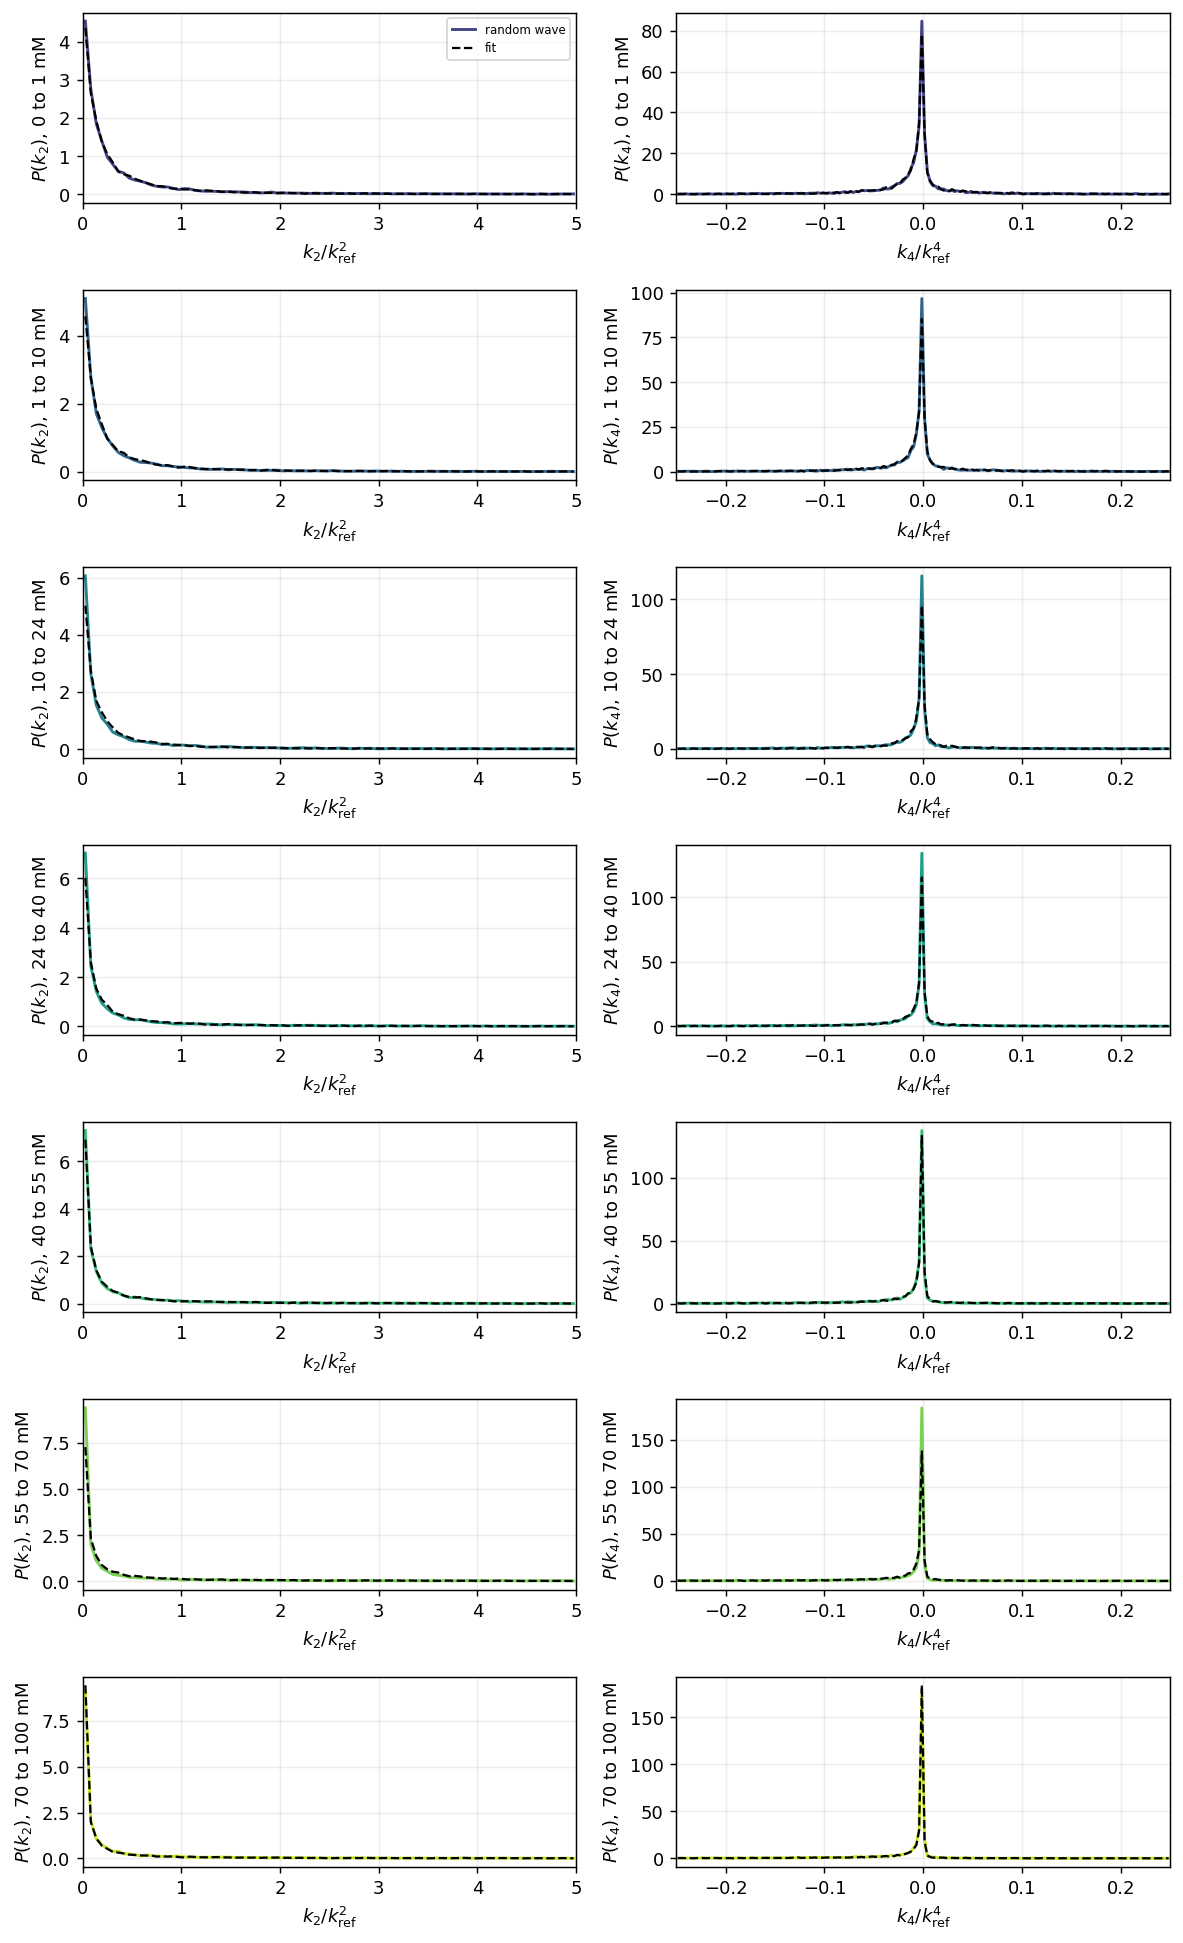

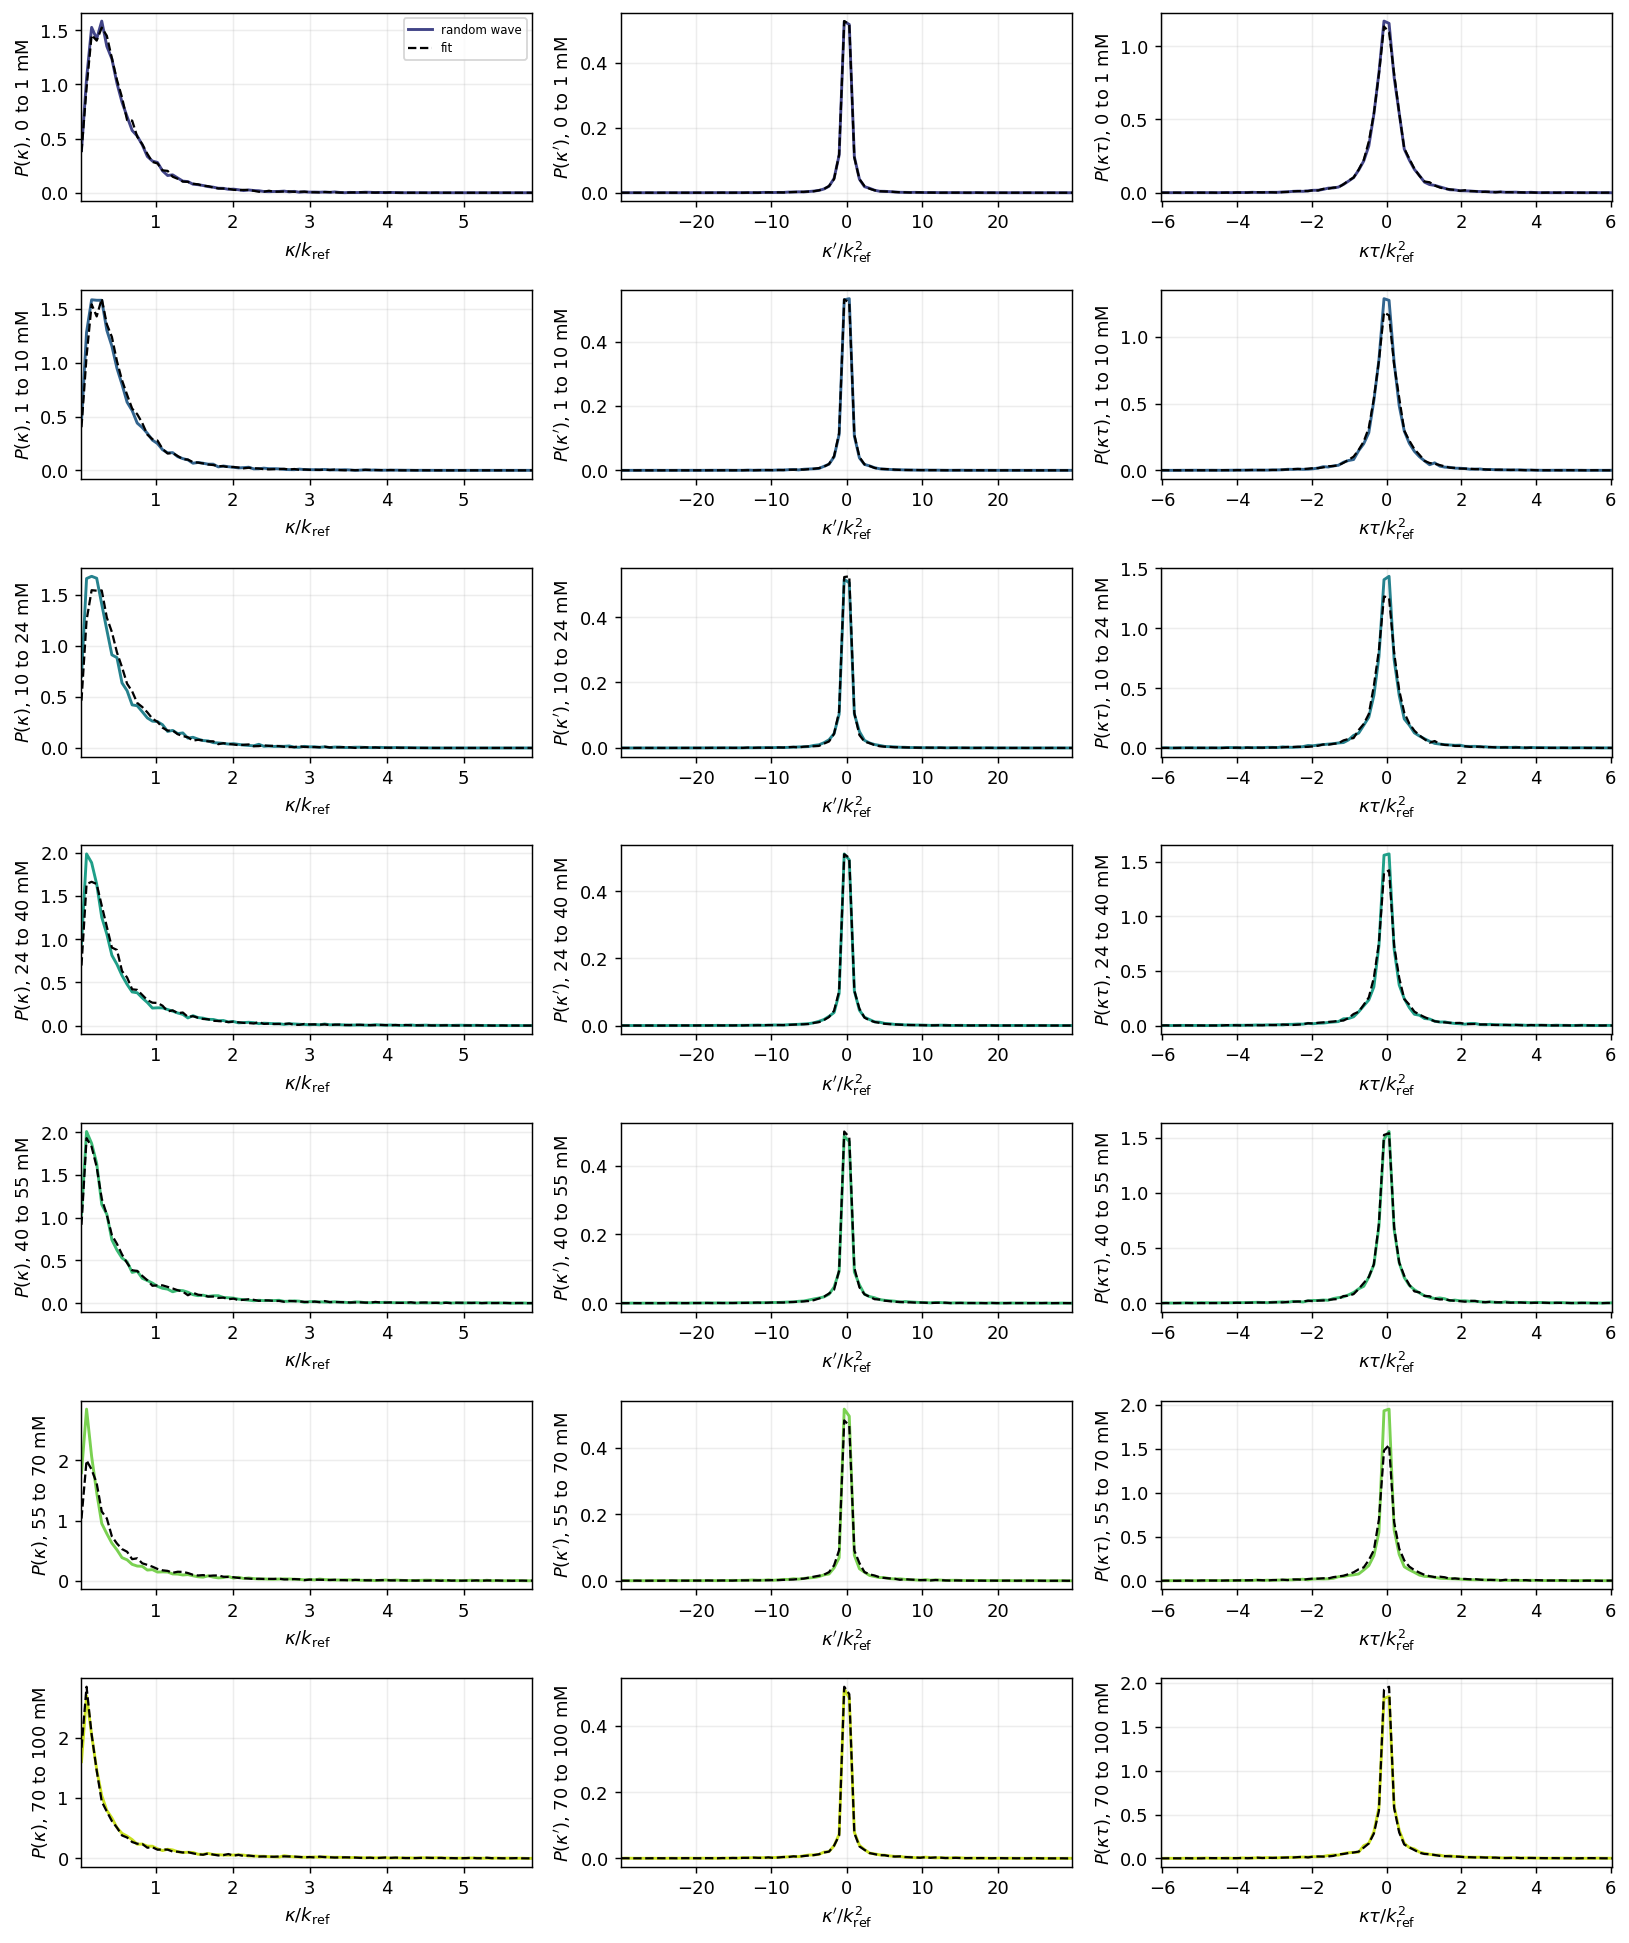

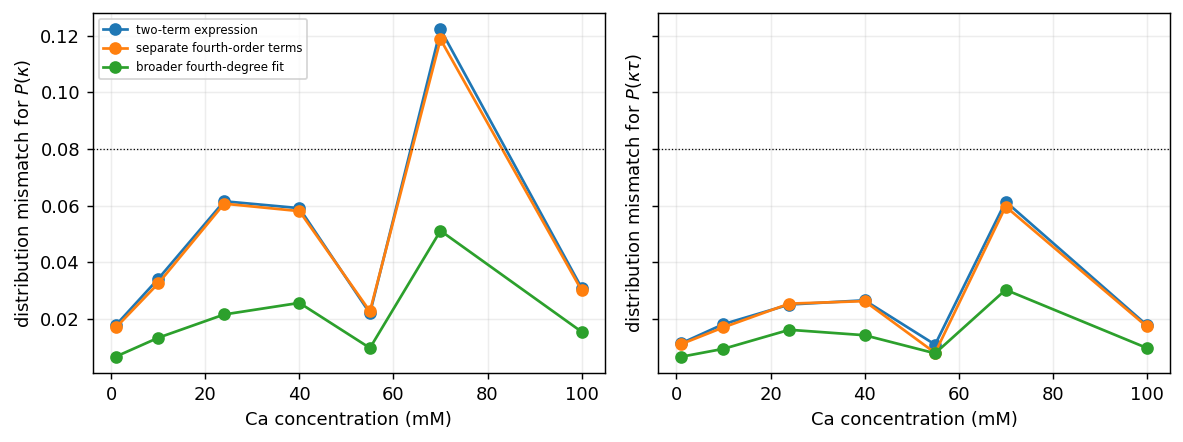

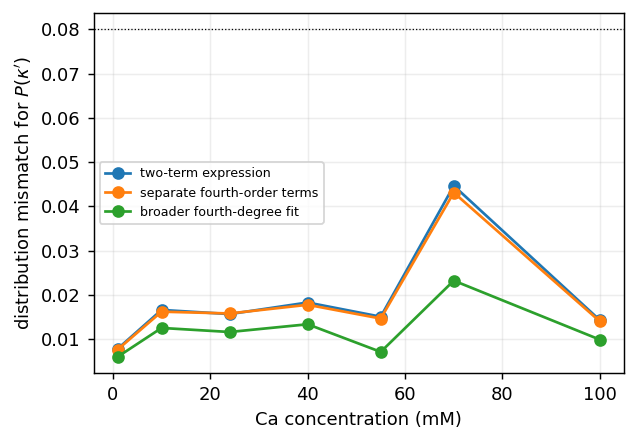

In [6]:
histogram_path = OUTPUT_DIR / "local_reconstruction_histograms.csv"
quality_path = OUTPUT_DIR / "local_reconstruction_quality.csv"
linked_distribution_adequate = False
if not histogram_path.exists() or not quality_path.exists():
    print("Fit artifacts are absent; run cf_ca_interaction_compute.ipynb with RUN_RANDOMWAVE_SAMPLING=True")
else:
    with histogram_path.open(newline="", encoding="utf-8") as handle:
        histogram_rows = list(csv.DictReader(handle))
    with quality_path.open(newline="", encoding="utf-8") as handle:
        reconstruction_quality_rows = list(csv.DictReader(handle))
    quality_by_salt = {float(row["concentration_mM"]): row for row in reconstruction_quality_rows}
    reconstruction_salt = sorted({float(row["concentration_mM"]) for row in histogram_rows})
    required_quality_columns = ("KS_kappa", "KS_kappa_prime", "KS_kappa_tau")
    if not all(column in reconstruction_quality_rows[0] for column in required_quality_columns):
        raise RuntimeError("The saved fit checks do not include kappa-prime; rerun local inference in the compute notebook")
    linked_distribution_adequate = all(max(float(quality_by_salt[float(value)][column]) for column in required_quality_columns) <= RECONSTRUCTION_KS_WARNING for value in reconstruction_salt)
    available_variables = {row["variable"] for row in histogram_rows}
    local_k2_name = "local_k2" if "local_k2" in available_variables else "linked_K2"
    local_k4_name = "local_k4" if "local_k4" in available_variables else "linked_K4"
    required_histogram_variables = {"kappa", "kappa_prime", "kappa_tau", local_k2_name, local_k4_name}
    if not required_histogram_variables.issubset(available_variables):
        raise RuntimeError("Saved distributions do not include local k2,k4; rerun local inference in the compute notebook")
    contour_histograms = []
    contour_histogram_path = OUTPUT_DIR / "contour_reconstruction_histograms.csv"
    if contour_histogram_path.exists():
        with contour_histogram_path.open(newline="", encoding="utf-8") as handle:
            saved_contour_histograms = list(csv.DictReader(handle))
        if saved_contour_histograms and saved_contour_histograms[0].get("normalization") == "common_kref" and np.isclose(float(saved_contour_histograms[0]["normalization_k_ref"]), k_ref):
            contour_histograms = saved_contour_histograms
        else:
            print("Saved contour distributions use an older normalization; rerun optional contour validation to overlay them.")
    else:
        print("Contour distributions are absent; showing random-wave measured and fit curves only.")
    corrected_histograms = []
    nonlocal_histogram_path = OUTPUT_DIR / "nonlocal_corrected_reconstruction_histograms.csv"
    if SHOW_DISTANT_CORRECTION_IN_FIT and nonlocal_histogram_path.exists():
        with nonlocal_histogram_path.open(newline="", encoding="utf-8") as handle:
            corrected_histograms = list(csv.DictReader(handle))
    elif SHOW_DISTANT_CORRECTION_IN_FIT:
        print("No saved distant-interaction correction is available; showing the uncorrected fit only.")
    fig, axes = plt.subplots(len(reconstruction_salt), 2, figsize=(9.2, 2.15*len(reconstruction_salt)), squeeze=False)
    for row_index, concentration in enumerate(reconstruction_salt):
        color = colors[np.flatnonzero(salt == concentration)[0]]
        for column_index, (variable, xlabel, ylabel, display_range) in enumerate(((local_k2_name, r"$k_2/k_{\rm ref}^2$", r"$P(k_2)$", LOCAL_K2_HISTOGRAM_RANGE), (local_k4_name, r"$k_4/k_{\rm ref}^4$", r"$P(k_4)$", LOCAL_K4_HISTOGRAM_RANGE))):
            rows = [row for row in histogram_rows if float(row["concentration_mM"]) == concentration and row["variable"] == variable]
            contour_rows = [row for row in contour_histograms if float(row["concentration_mM"]) == concentration and row["variable"] == ("local_k2" if variable == local_k2_name else "local_k4")]
            legacy_range_factor = LOCAL_EXPANSION_RANGE_MULTIPLIER if variable.startswith("linked_") else 1.0
            coordinate = np.array([float(row["coordinate"]) for row in rows]) / legacy_range_factor
            axis = axes[row_index,column_index]
            axis.plot(coordinate, legacy_range_factor*np.array([float(row["measured_density"]) for row in rows]), color=color, lw=1.6, label="random wave")
            axis.plot(coordinate, legacy_range_factor*np.array([float(row["fit_density"]) for row in rows]), color="k", lw=1.25, ls="--", label="fit")
            if contour_rows:
                axis.plot([float(row["coordinate"]) for row in contour_rows], [float(row["measured_density"]) for row in contour_rows], color="0.45", lw=1.2, label="contour trace")
            source_salt = source_salt_by_target[concentration]
            axis.set(xlabel=xlabel, ylabel=f"{ylabel}, {source_salt:g} to {concentration:g} mM", xlim=display_range)
    axes[0,0].legend(fontsize=6.5)
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "local_k2_k4_fit.png"); plt.show()
    fig, axes = plt.subplots(len(reconstruction_salt), 3, figsize=(12.6, 2.15*len(reconstruction_salt)), squeeze=False)
    for row_index, concentration in enumerate(reconstruction_salt):
        color = colors[np.flatnonzero(salt == concentration)[0]]
        quality = quality_by_salt[float(concentration)]
        for column_index, (variable, xlabel, ylabel) in enumerate((("kappa", r"$\kappa/k_{\rm ref}$", r"$P(\kappa)$"), ("kappa_prime", r"$\kappa'/k_{\rm ref}^2$", r"$P(\kappa')$"), ("kappa_tau", r"$\kappa\tau/k_{\rm ref}^2$", r"$P(\kappa\tau)$"))):
            rows = [row for row in histogram_rows if float(row["concentration_mM"]) == concentration and row["variable"] == variable]
            contour_rows = [row for row in contour_histograms if float(row["concentration_mM"]) == concentration and row["variable"] == variable]
            coordinate = np.array([float(row["coordinate"]) for row in rows])
            measured_density = np.array([float(row["measured_density"]) for row in rows])
            fit_density = np.array([float(row["fit_density"]) for row in rows])
            axis = axes[row_index, column_index]
            axis.plot(coordinate, measured_density, color=color, lw=1.6, label="random wave")
            axis.plot(coordinate, fit_density, color="k", lw=1.25, ls="--", label="fit")
            if contour_rows:
                axis.plot([float(row["coordinate"]) for row in contour_rows], [float(row["measured_density"]) for row in contour_rows], color="0.45", lw=1.2, label="contour trace")
            corrected_rows = [row for row in corrected_histograms if float(row["concentration_mM"]) == concentration and row["variable"] == variable]
            if corrected_rows:
                corrected_coordinate = np.array([float(row["coordinate"]) for row in corrected_rows])
                corrected_density = np.array([float(row["fit_density"]) for row in corrected_rows])
                axis.plot(corrected_coordinate, corrected_density, color="tab:red", lw=1.2, ls="-.", label="fit with distant correction")
            source_salt = source_salt_by_target[concentration]
            axis.set(xlabel=xlabel, ylabel=f"{ylabel}, {source_salt:g} to {concentration:g} mM", xlim=(coordinate.min(), coordinate.max()))
    axes[0,0].legend(fontsize=6.5)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "local_X_fit.png")
    plt.show()
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.5), sharex=True, sharey=True)
    for axis, variable, ylabel in zip(axes, ("kappa", "kappa_tau"), (r"KS for $P(\kappa)$", r"KS for $P(\kappa\tau)$")):
        linked_ks = np.array([float(quality_by_salt[float(value)][f"KS_{variable}"]) for value in reconstruction_salt])
        independent_ks = np.array([float(quality_by_salt[float(value)][f"KS_{variable}_independent"]) for value in reconstruction_salt])
        flexible_ks = np.array([float(quality_by_salt[float(value)][f"KS_{variable}_flexible"]) for value in reconstruction_salt])
        axis.plot(reconstruction_salt, linked_ks, marker="o", label="two-term expression")
        axis.plot(reconstruction_salt, independent_ks, marker="o", label="separate fourth-order terms")
        axis.plot(reconstruction_salt, flexible_ks, marker="o", label="broader fourth-degree fit")
        axis.axhline(RECONSTRUCTION_KS_WARNING, color="k", lw=0.7, ls=":")
        axis.set(xlabel="Ca concentration (mM)", ylabel=ylabel.replace("KS for", "distribution mismatch for"))
    axes[0].legend(fontsize=6.5)
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "local_reconstruction_model_quality.png"); plt.show()
    fig, axis = plt.subplots(figsize=(5.0, 3.5))
    axis.plot(reconstruction_salt, [float(quality_by_salt[float(value)]["KS_kappa_prime"]) for value in reconstruction_salt], marker="o", label="two-term expression")
    axis.plot(reconstruction_salt, [float(quality_by_salt[float(value)]["KS_kappa_prime_independent"]) for value in reconstruction_salt], marker="o", label="separate fourth-order terms")
    axis.plot(reconstruction_salt, [float(quality_by_salt[float(value)]["KS_kappa_prime_flexible"]) for value in reconstruction_salt], marker="o", label="broader fourth-degree fit")
    axis.axhline(RECONSTRUCTION_KS_WARNING, color="k", lw=0.7, ls=":")
    axis.set(xlabel="Ca concentration (mM)", ylabel=r"distribution mismatch for $P(\kappa')$")
    axis.legend(fontsize=7)
    fig.tight_layout(); fig.savefig(OUTPUT_DIR / "local_kappaprime_model_quality.png"); plt.show()
    for concentration in reconstruction_salt:
        quality = quality_by_salt[float(concentration)]
        worst = max(float(quality["KS_kappa"]), float(quality["KS_kappa_prime"]), float(quality["KS_kappa_tau"]))
        if worst > RECONSTRUCTION_KS_WARNING:
            print(f"WARNING: {concentration:g} mM is not well reproduced by the two-term expression (largest distribution mismatch={worst:.3f}).")

## 4. Conditional interaction comparison

The reference assumption and cutoff approximation are selected independently. `CONDITIONAL_REFERENCE_MODE="fixed"` uses the stated $g_0,D_0$, while `"family"` scans plausible references. `CONDITIONAL_CUTOFF_MODE="short_range"` sets $f_2=f_4=1$, while `"finite_cutoff"` retains the cutoff factors. Every result remains conditional on its selected reference treatment.

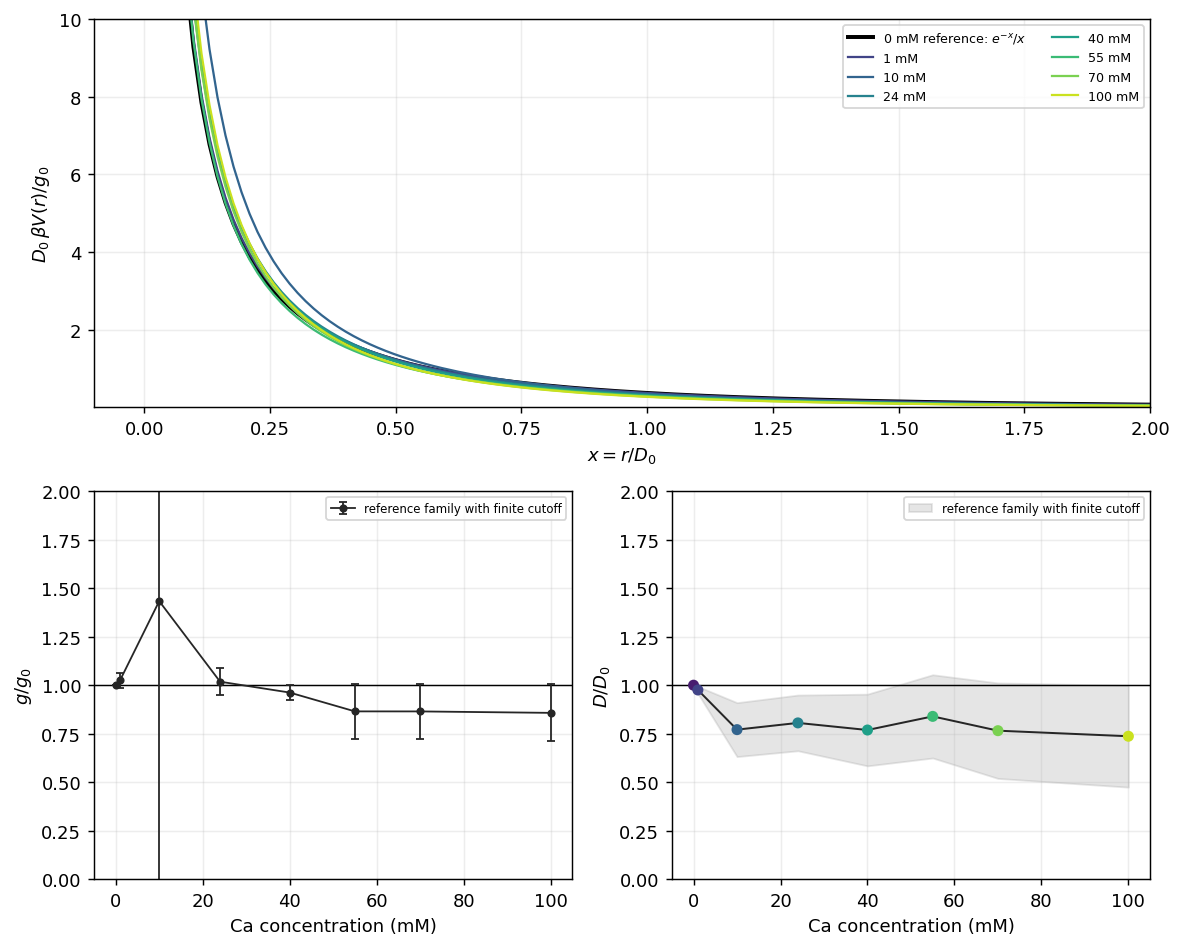

reference-family choices used: 284 of 289; cutoff mode=finite_cutoff


In [7]:
if not linked_distribution_adequate:
    print("WARNING: interaction-parameter plots are conditional diagnostics because linked Delta c2,Delta c4 do not reproduce every observable distribution")
mapping_delta_c2 = cumulative_delta_c2
mapping_delta_c4 = cumulative_delta_c4
mapping_coefficient_covariances = cumulative_coefficient_covariances
reference_ell_kref = LOCAL_EXPANSION_RANGE_MULTIPLIER
target_ell_kref = LOCAL_EXPANSION_RANGE_MULTIPLIER * k_ref / k_eff
envelope_sigma = CONDITIONAL_ENVELOPE_STANDARD_DEVIATIONS
if CONDITIONAL_REFERENCE_MODE == "fixed" and CONDITIONAL_CUTOFF_MODE == "short_range":
    if "projection_effective_count" not in coefficient_rows[0]:
        raise RuntimeError("Saved coefficient errors use the old inflated normalization; rerun the fourth-degree fit cell in cf_ca_interaction_compute.ipynb")
    short_range_a0 = FIXED_REFERENCE_G0_OVER_KREF * FIXED_REFERENCE_D0_KREF**2 / 8.0
    short_range_c40 = FIXED_REFERENCE_G0_OVER_KREF * FIXED_REFERENCE_D0_KREF**4
    short_g, short_d = interaction.short_range_relative_yukawa_parameters(
        mapping_delta_c2, mapping_delta_c4, short_range_a0, short_range_c40
    )
    short_errors = np.array([interaction.short_range_relative_yukawa_uncertainty(
        mapping_delta_c2[index], mapping_delta_c4[index], mapping_coefficient_covariances[index],
        short_range_a0, short_range_c40,
    ) for index in range(len(salt))])
    g_plot_summary = np.column_stack((short_g, short_errors[:, 0]))
    d_plot_summary = np.column_stack((short_d, short_errors[:, 1]))
    interaction_mapping = r"conditional short-range, $\pm1\sigma$"
    reported_sigma = 1.0
elif CONDITIONAL_REFERENCE_MODE == "fixed":
    fixed_a0, fixed_c40 = interaction.yukawa_dimensionless_coefficients(FIXED_REFERENCE_G0_OVER_KREF, FIXED_REFERENCE_D0_KREF, reference_ell_kref)
    fixed_g, fixed_d = interaction.relative_yukawa_parameters(mapping_delta_c2, mapping_delta_c4, float(fixed_a0), float(fixed_c40), ell_kref=target_ell_kref, reference_ell_kref=reference_ell_kref)
    fixed_errors = np.array([interaction.relative_yukawa_uncertainty(mapping_delta_c2[index], mapping_delta_c4[index], mapping_coefficient_covariances[index], float(fixed_a0), float(fixed_c40), ell_kref=target_ell_kref[index], reference_ell_kref=reference_ell_kref) for index in range(len(salt))])
    g_plot_summary = np.column_stack((fixed_g, fixed_errors[:,0]))
    d_plot_summary = np.column_stack((fixed_d, fixed_errors[:,1]))
    interaction_mapping = r"fixed reference with cutoff factors, $\pm1\sigma$"
    reported_sigma = 1.0
else:
    g0_grid = np.geomspace(*CONDITIONAL_G0_OVER_KREF_BOUNDS, CONDITIONAL_REFERENCE_GRID_SIZE)
    d0_grid = np.geomspace(*CONDITIONAL_D0_KREF_BOUNDS, CONDITIONAL_REFERENCE_GRID_SIZE)
    if CONDITIONAL_CUTOFF_MODE == "short_range":
        common_family = interaction.conditional_short_range_yukawa_family(mapping_delta_c2, mapping_delta_c4, g0_grid, d0_grid)
        structural_family = common_family
    else:
        common_family = interaction.conditional_relative_yukawa_family(mapping_delta_c2, mapping_delta_c4, g0_grid, d0_grid, ell_kref=np.full_like(salt, reference_ell_kref), reference_ell_kref=reference_ell_kref)
        structural_family = interaction.conditional_relative_yukawa_family(mapping_delta_c2, mapping_delta_c4, g0_grid, d0_grid, ell_kref=target_ell_kref, reference_ell_kref=reference_ell_kref)
    joint_valid = np.all(common_family.valid, axis=1) & np.all(structural_family.valid, axis=1)
    if not np.any(joint_valid):
        raise RuntimeError("No reference choice is valid for both cutoff mappings across the full salt series")
    reference_ddof = 1 if joint_valid.sum() > 1 else 0
    g_common_values = common_family.g_over_g0[joint_valid]
    g_structural_values = structural_family.g_over_g0[joint_valid]
    d_values = structural_family.d_over_d0[joint_valid]
    g_common_summary = np.column_stack((np.mean(g_common_values, axis=0), np.std(g_common_values, axis=0, ddof=reference_ddof)))
    g_structural_summary = np.column_stack((np.mean(g_structural_values, axis=0), np.std(g_structural_values, axis=0, ddof=reference_ddof)))
    d_summary = np.column_stack((np.mean(d_values, axis=0), np.std(d_values, axis=0, ddof=reference_ddof)))
    g_plot_summary = g_common_summary
    d_plot_summary = d_summary
    interaction_mapping = f"reference family with {CONDITIONAL_CUTOFF_MODE.replace('_', ' ')}"
    reported_sigma = envelope_sigma
reduced_distance = np.linspace(0.05, 8.0, 500)
fig = plt.figure(figsize=(9.2, 7.4))
grid = fig.add_gridspec(2, 2)
potential_axis = fig.add_subplot(grid[0, :])
g_axis = fig.add_subplot(grid[1, 0])
d_axis = fig.add_subplot(grid[1, 1])
reference_label = f"{reference_salt:g} mM reference"
g_ratio_label = r"$g/g_0$" if np.isclose(reference_salt, 0.0) else r"$g/g_{\rm ref}$"
d_ratio_label = r"$D/D_0$" if np.isclose(reference_salt, 0.0) else r"$D/D_{\rm ref}$"
distance_label = r"$x=r/D_0$" if np.isclose(reference_salt, 0.0) else r"$x=r/D_{\rm ref}$"
potential_label = r"$D_0\,\beta V(r)/g_0$" if np.isclose(reference_salt, 0.0) else r"$D_{\rm ref}\,\beta V(r)/g_{\rm ref}$"
potential_axis.plot(reduced_distance, np.exp(-reduced_distance) / reduced_distance, color="k", lw=2.2, label=reference_label + ": $e^{-x}/x$")
for color, index, concentration in zip(colors, range(len(salt)), salt):
    if index == reference_index:
        continue
    if CONDITIONAL_REFERENCE_MODE == "fixed":
        profile = interaction.normalized_yukawa_profile(reduced_distance, g_plot_summary[index,0], d_plot_summary[index,0])
    else:
        profiles = interaction.normalized_yukawa_profile(reduced_distance, structural_family.g_over_g0[joint_valid, index], structural_family.d_over_d0[joint_valid, index])
        profile = np.mean(profiles, axis=0)
    potential_axis.plot(reduced_distance, profile, color=color, lw=1.25, label=f"{concentration:g} mM")

g_axis.axhline(1.0, color="k", lw=0.8)
g_axis.errorbar(salt, g_plot_summary[:, 0], yerr=reported_sigma*g_plot_summary[:, 1], color="0.15", marker="o", ms=3.5, lw=1.0, capsize=2, label=interaction_mapping)
g_axis.set(xlabel="Ca concentration (mM)", ylabel=g_ratio_label)
g_axis.set_ylim(0.0, 2)
g_axis.legend(fontsize=6.5)

for axis, summary, ylabel in ((d_axis, d_plot_summary, d_ratio_label),):
    axis.axhline(1.0, color="k", lw=0.8)
    lower = np.maximum(summary[:, 0]-reported_sigma*summary[:, 1], 0.0)
    upper = summary[:, 0]+reported_sigma*summary[:, 1]
    axis.fill_between(salt, lower, upper, color="0.55", alpha=0.22, label=interaction_mapping)
    axis.plot(salt, summary[:, 0], color="0.15", lw=1.1)
    axis.scatter(salt, summary[:, 0], c=colors, s=26, zorder=3)
    axis.set(xlabel="Ca concentration (mM)", ylabel=ylabel)
    axis.legend(fontsize=6.5)
potential_axis.set(xlabel=distance_label, ylabel=potential_label, 
                   xscale="linear", yscale="linear", xlim=(-0.1, 2.0), ylim=(1e-2, 10.0))
potential_axis.legend(fontsize=7, ncol=2)

d_axis.set_ylim(0.0, 2.00)
fig.tight_layout()
interaction_figure = f"conditional_{CONDITIONAL_REFERENCE_MODE}_{CONDITIONAL_CUTOFF_MODE}_yukawa_comparison.png"
fig.savefig(OUTPUT_DIR / interaction_figure)
plt.show()
if CONDITIONAL_REFERENCE_MODE == "fixed":
    print(f"fixed reference: g0/k_ref={FIXED_REFERENCE_G0_OVER_KREF:g}, D0*k_ref={FIXED_REFERENCE_D0_KREF:g}; cutoff mode={CONDITIONAL_CUTOFF_MODE}")
else:
    print(f"reference-family choices used: {joint_valid.sum()} of {len(joint_valid)}; cutoff mode={CONDITIONAL_CUTOFF_MODE}")

In [8]:
if CONDITIONAL_REFERENCE_MODE == "fixed":
    summary_rows = [{
        "concentration_mM": concentration, "mapping": interaction_mapping,
        "g_over_g0": g_plot_summary[index, 0], "g_over_g0_error": g_plot_summary[index, 1],
        "D_over_D0": d_plot_summary[index, 0], "D_over_D0_error": d_plot_summary[index, 1],
        "g0_over_kref": FIXED_REFERENCE_G0_OVER_KREF, "D0_kref": FIXED_REFERENCE_D0_KREF, "cutoff_mode": CONDITIONAL_CUTOFF_MODE,
    } for index, concentration in enumerate(salt)]
    summary_filename = f"conditional_fixed_{CONDITIONAL_CUTOFF_MODE}_yukawa_summary.csv"
else:
    summary_rows = [{
        "concentration_mM": concentration,
        "k_eff_over_kref": k_eff[index] / k_ref,
        "target_ell_kref": target_ell_kref[index],
        "joint_valid_reference_count": int(joint_valid.sum()),
        "cutoff_mode": CONDITIONAL_CUTOFF_MODE,
        "g_over_g0_common_cutoff_mean": g_common_summary[index, 0], "g_over_g0_common_cutoff_std": g_common_summary[index, 1],
        "g_over_g0_condition_cutoff_mean": g_structural_summary[index, 0], "g_over_g0_condition_cutoff_std": g_structural_summary[index, 1],
        "D_over_D0_condition_cutoff_mean": d_summary[index, 0], "D_over_D0_condition_cutoff_std": d_summary[index, 1],
    } for index, concentration in enumerate(salt)]
    summary_filename = f"conditional_family_{CONDITIONAL_CUTOFF_MODE}_yukawa_summary.csv"
with (OUTPUT_DIR / summary_filename).open("w", newline="", encoding="utf-8") as handle:
    writer = csv.DictWriter(handle, fieldnames=list(summary_rows[0]))
    writer.writeheader(); writer.writerows(summary_rows)
print(f"saved {interaction_mapping} summary for {len(summary_rows)} salt conditions")

saved reference family with finite cutoff summary for 8 salt conditions


## 5. Random-wave line-density matching

The reported $\Delta c_2$ and $\Delta c_4$ are fitted to the random-wave samples. This figure therefore treats the random-wave target and random-wave fit as the primary comparison. Traced-contour values and their separate fit are shown only as an optional resolution and finite-size check. All curves are line densities using the same fixed reference normalization: $\langle k_2\rangle/k_{\rm ref}^2=(K_2/L)/k_{\rm ref}^2$ and $\langle k_4\rangle/k_{\rm ref}^4=(K_4/L)/k_{\rm ref}^4$. No contour-length ratio or three-dimensional cell volume is applied.

Contour validation is absent; only the primary random-wave comparison is shown.


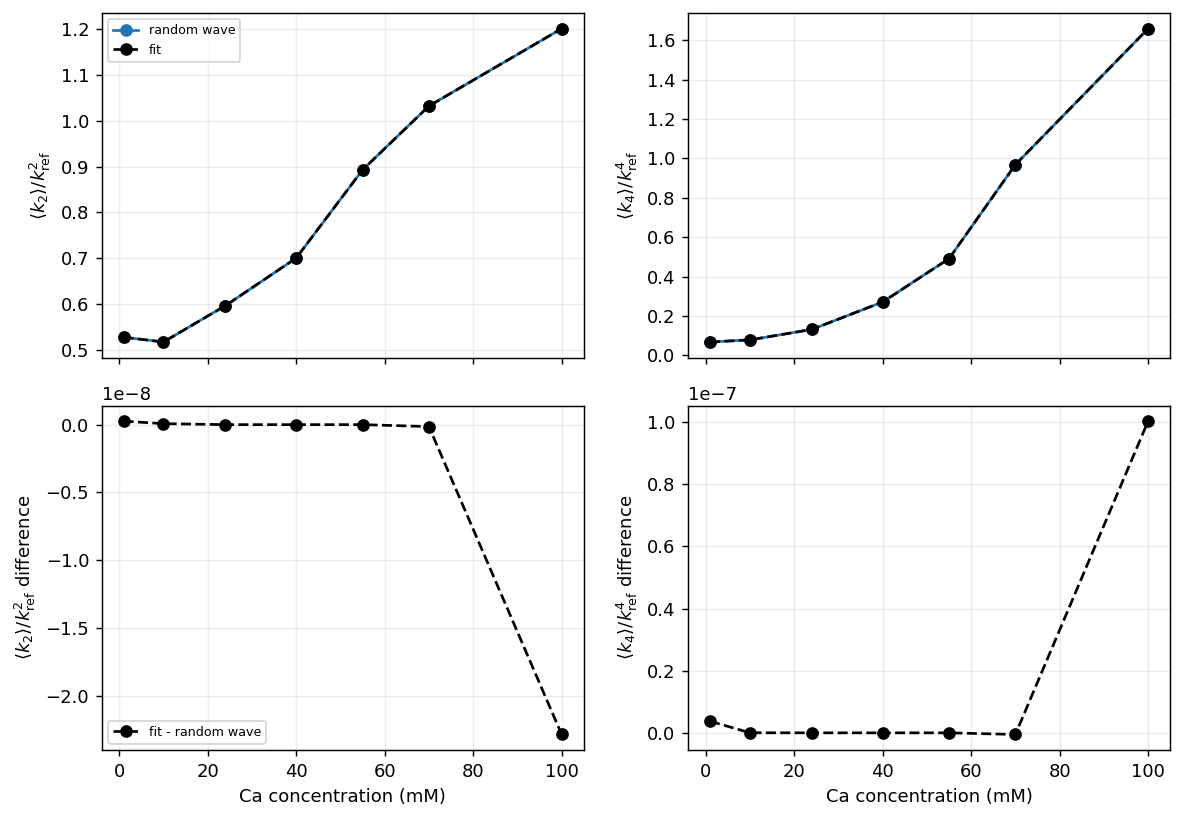

In [9]:
randomwave_rows = [row for row in coefficient_rows if row["randomwave_target_K2_over_ksource"].lower() != "nan"]
comparison_salt = np.array([float(row["concentration_mM"]) for row in randomwave_rows])
source_scale = np.array([float(row["source_k_eff"])/k_ref for row in randomwave_rows])
randomwave_k2 = np.array([float(row["randomwave_target_K2_over_ksource"]) for row in randomwave_rows]) * source_scale**2 / LOCAL_EXPANSION_RANGE_MULTIPLIER
randomwave_fitted_k2 = np.array([float(row["randomwave_fitted_K2_over_ksource"]) for row in randomwave_rows]) * source_scale**2 / LOCAL_EXPANSION_RANGE_MULTIPLIER
randomwave_k4 = np.array([float(row["randomwave_target_K4_over_ksource3"]) for row in randomwave_rows]) * source_scale**4 / LOCAL_EXPANSION_RANGE_MULTIPLIER
randomwave_fitted_k4 = np.array([float(row["randomwave_fitted_K4_over_ksource3"]) for row in randomwave_rows]) * source_scale**4 / LOCAL_EXPANSION_RANGE_MULTIPLIER
contour_values = None
contour_validation_path = OUTPUT_DIR / "contour_validation.csv"
if contour_validation_path.exists():
    with contour_validation_path.open(newline="", encoding="utf-8") as handle:
        contour_validation_rows = list(csv.DictReader(handle))
    contour_columns = {"contour_target_k2_density_over_kref2", "contour_fitted_k2_density_over_kref2", "contour_target_k4_density_over_kref4", "contour_fitted_k4_density_over_kref4"}
    if contour_validation_rows and contour_columns.issubset(contour_validation_rows[0]):
        contour_by_salt = {float(row["concentration_mM"]): row for row in contour_validation_rows}
        if all(value in contour_by_salt for value in comparison_salt):
            contour_k2 = np.array([float(contour_by_salt[value]["contour_target_k2_density_over_kref2"]) for value in comparison_salt])
            contour_fitted_k2 = np.array([float(contour_by_salt[value]["contour_fitted_k2_density_over_kref2"]) for value in comparison_salt])
            contour_k4 = np.array([float(contour_by_salt[value]["contour_target_k4_density_over_kref4"]) for value in comparison_salt])
            contour_fitted_k4 = np.array([float(contour_by_salt[value]["contour_fitted_k4_density_over_kref4"]) for value in comparison_salt])
            contour_values = (contour_k2, contour_fitted_k2, contour_k4, contour_fitted_k4)
    if contour_values is None:
        print("Saved contour validation uses an older normalization; only the primary random-wave comparison is shown.")
else:
    print("Contour validation is absent; only the primary random-wave comparison is shown.")
fig, axes = plt.subplots(2, 2, figsize=(9.2, 6.4), sharex=True)
for axis, randomwave_value, randomwave_fit, ylabel in ((axes[0,0], randomwave_k2, randomwave_fitted_k2, r"$\langle k_2\rangle/k_{\rm ref}^2$"), (axes[0,1], randomwave_k4, randomwave_fitted_k4, r"$\langle k_4\rangle/k_{\rm ref}^4$")):
    axis.plot(comparison_salt, randomwave_value, marker="o", label="random wave")
    axis.plot(comparison_salt, randomwave_fit, color="k", marker="o", ls="--", label="fit")
    axis.set(ylabel=ylabel)
axes[1,0].plot(comparison_salt, randomwave_fitted_k2-randomwave_k2, color="k", marker="o", ls="--", label="fit - random wave")
axes[1,1].plot(comparison_salt, randomwave_fitted_k4-randomwave_k4, color="k", marker="o", ls="--")
if contour_values is not None:
    axes[0,0].plot(comparison_salt, contour_k2, color="0.45", marker="s", label="contour trace")
    axes[0,0].plot(comparison_salt, contour_fitted_k2, color="0.45", marker="s", ls=":", label="contour fit")
    axes[0,1].plot(comparison_salt, contour_k4, color="0.45", marker="s", label="contour trace")
    axes[0,1].plot(comparison_salt, contour_fitted_k4, color="0.45", marker="s", ls=":", label="contour fit")
    axes[1,0].plot(comparison_salt, contour_k2-randomwave_k2, marker="o", label="contour trace - random wave")
    axes[1,1].plot(comparison_salt, contour_k4-randomwave_k4, marker="o")
axes[1,0].set(xlabel="Ca concentration (mM)", ylabel=r"$\langle k_2\rangle/k_{\rm ref}^2$ difference")
axes[1,1].set(xlabel="Ca concentration (mM)", ylabel=r"$\langle k_4\rangle/k_{\rm ref}^4$ difference")
axes[0,0].legend(fontsize=7); axes[1,0].legend(fontsize=7)
fig.tight_layout(); fig.savefig(OUTPUT_DIR / "k2_k4_line_density_comparison.png"); plt.show()